# Phase 3: Simple Linear Regression and Model Evaluation

This phase builds directly on your Phase 2 EDA. You are no longer just exploring data — you are now using it to make predictions.

**The goal of this phase is to:**
- Understand the modeling pipeline from feature selection to evaluation
- Build a constant model as a baseline
- Build a Simple Linear Regression model from scratch
- Understand what a loss function is and visualize the loss surface
- Evaluate your model using MSE, RMSE, and R-squared
- Diagnose your model using residual analysis
- Attempt a Multiple Linear Regression with a second feature

This is your introduction to modeling as a reasoning process, not a copy-paste exercise.

---

## Submission Requirements

Submit the following:
- Jupyter Notebook (`.ipynb`)
- All dataset files used
- A short README section at the top of your notebook

---

## Overview of our Phase 3

*"How heavily did a state’s COVID-19 measurement policy have an impact on mental health compared to its counterparts?"*

- Feature: StringencyIndex_Average
- Target: Value
- Final dataset shape: (3804, 45)
Shape of combined df: (3804, 45)
We choose this feature, as it is the primary indicator for our research question and the EDA showed us a relationship between the feature and target variable, even through it is a weak one.

In [11]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./dataset/cleaned_dataset.csv')

## Part 1: Feature and Target Selection

Before writing a single line of modeling code, you must justify your choices using evidence from Phase 2.

**You must clearly state:**
- Your target variable (what you are predicting)
- Your chosen feature (what you are using to predict it)
- The scatter plot from Phase 2 that shows a relationship exists
- The correlation value between your feature and target

**You must include this sentence exactly:**

> I am predicting ______ using ______ because my Phase 2 EDA showed ______.

This is required. If your Phase 2 EDA did not reveal a useful feature, you must explain why you are trying a different one and what you expect to find.

> **Note:** A feature that does not improve your model is still a valid result. You are testing whether it works, not proving that it does.

We are predicing 'Value' using 'StringencyIndex_Average' because our scatterplot showed that there is a positive relationship between the two.

We try to predict the 'Value' of the dataset, which is an reported value of the depression and anxiety rates among the survey participants. We are using the 'StringencyIndex_Average' value as the feature, which is a summary of how strict the Covid policies were during that time. As we did not include a scatter plot in our Phase 2, we plotted some that are related to our research question. We also did a graph for all combined rows, the rows that were either specifically capturing anxiety or depression rates, as well as the rows that captured both of them. We can see, that there is a visible relationship between the target and feature for all plots, which we analyze in this Phase into more detail, as it is the primary indicator for our research question. We will focus on the rows which captured both depression and anxiety, as its plot indicates the strongest relationship.

Numeric columns and their ranges:
    Time Period: 1.00 to 52.00
    Time Period Start Date: 20200423.00 to 20221209.00
    Time Period End Date: 20200505.00 to 20221219.00
    Value: 6.40 to 82.00
    Low CI: 4.50 to 73.60
    High CI: 7.90 to 88.80
    C1M_combined_numeric: 0.00 to 3.00
    C2M_combined_numeric: 0.00 to 3.00
    C3M_combined_numeric: 0.00 to 2.00
    C4M_combined_numeric: 0.00 to 4.00
    C5M_combined_numeric: 0.00 to 2.00
    C6M_combined_numeric: 0.00 to 2.00
    C7M_combined_numeric: 0.00 to 2.00
    C8EV_combined_numeric: 1.00 to 3.00
    E1_combined_numeric: 0.00 to 2.00
    E2_combined_numeric: 0.00 to 2.00
    H1_combined_numeric: 1.50 to 2.00
    H2_combined_numeric: 1.00 to 3.00
    H3_combined_numeric: 1.00 to 2.00
    H6M_combined_numeric: 0.00 to 4.00
    H7_combined_numeric: 0.00 to 5.00
    H8M_combined_numeric: 0.50 to 3.00
    V1..summary.: 0.00 to 2.00
    V2..summary.: 0.00 to 3.00
    V3..summary.: 0.00 to 5.00
    V4..summary.: 0.00 to 1.00
    Co

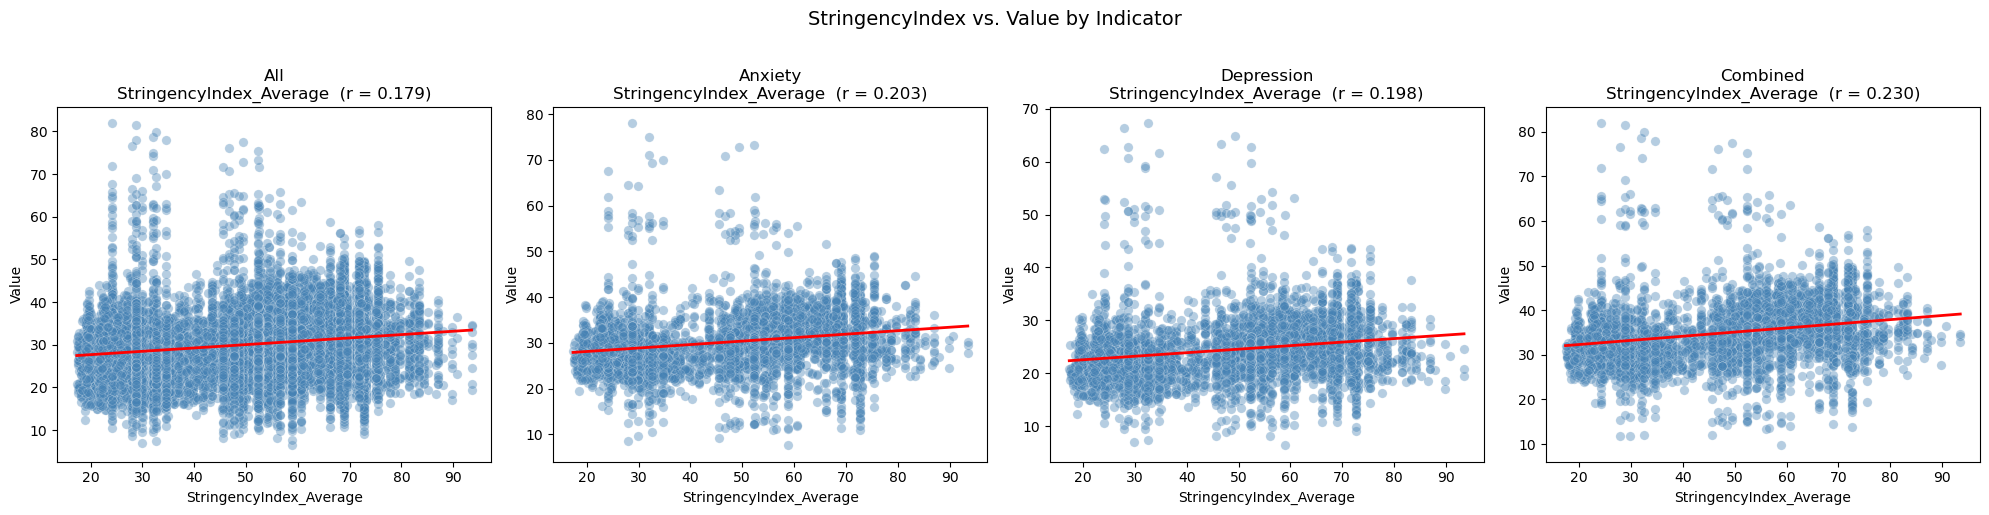

Shape of original df: (11412, 45)
Shape of anxiety df: (3804, 45)
Shape of depression df: (3804, 45)
Shape of combined df: (3804, 45)


In [49]:
# Scatter plot

# Second df: Filter for Symptoms of Anxiety Disorder and for State == United States
df_anxiety = df[df['Indicator'] == 'Symptoms of Anxiety Disorder']
# Third df: Filter for Symptoms of Depressive Disorder
df_depression = df[df['Indicator'] == 'Symptoms of Depressive Disorder']
# Fourth df: Filter for Symptoms of Anxiety or Depressive Disorder
df_combined = df[df['Indicator'] == 'Symptoms of Anxiety Disorder or Depressive Disorder']

# Print out lowest and highest values for each numeric column
print("Numeric columns and their ranges:")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"    {col}: {df[col].min():.2f} to {df[col].max():.2f}")

def plot_scatter(dataframes: list, numeric_cols: list, labels: list = None):
    cols = len(dataframes)
    rows = len(numeric_cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    
    # Normalize to 2D array
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    for col_idx, df in enumerate(dataframes):
        for row_idx, col in enumerate(numeric_cols):
            ax = axes[row_idx, col_idx]
            ax.scatter(df[col], df['Value'], alpha=0.4, color='steelblue',
                       edgecolors='white', linewidths=0.3, s=45)
            r = df[col].corr(df['Value'])
            x, y = df[col], df['Value']
            mask = x.notna() & y.notna()
            z = np.polyfit(x[mask], y[mask], 1)
            p = np.poly1d(z)
            ax.plot(sorted(x[mask]), p(sorted(x[mask])), color='red', linewidth=2)
            ax.set_xlabel(col)
            ax.set_ylabel("Value")
            title = labels[col_idx] if labels else f"df[{col_idx}]"
            ax.set_title(f"{title}\n{col}  (r = {r:.3f})")

    plt.suptitle("StringencyIndex vs. Value by Indicator", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("08_feature_correlations.png", dpi=120, bbox_inches='tight')
    plt.show()

labels = ['All', 'Anxiety', 'Depression', 'Combined']
numeric_cols = ['StringencyIndex_Average']
dataframes = [df, df_anxiety, df_depression, df_combined]
plot_scatter(dataframes, numeric_cols, labels=labels)

# Print the shape of each dataframe
print(f"Shape of original df: {df.shape}")
print(f"Shape of anxiety df: {df_anxiety.shape}")
print(f"Shape of depression df: {df_depression.shape}")
print(f"Shape of combined df: {df_combined.shape}")


---

## Part 2: Constant Model Baseline


Every model needs a baseline. The constant model is the simplest possible prediction rule: predict the same value for every row.

You must implement the following:

    constant_prediction = df['target'].mean()
    df['pred_constant'] = constant_prediction
    df['error'] = df['target'] - df['pred_constant']
    df['squared_error'] = df['error'] ** 2

**You must then compute and display:**
- MSE of the constant model
- RMSE of the constant model
- A written interpretation of what the RMSE means in the context of your dataset, using the actual units of your target variable

MSE is in squared units and is not directly interpretable. RMSE takes the square root and brings the error back into the same units as your target variable, which means you can make a statement a human can actually understand. Use MSE when comparing models mathematically. Use RMSE when interpreting results.

**Example:** If your RMSE is 14.3 and your target is exam score, write: *"On average, the constant model is off by 14.3 points. This is our baseline. Any model we build must beat this number to be considered useful."*

> **A model that cannot beat the constant model is useless. This is not optional context. This is the whole point.**

In [50]:
# Get the mean for the target = Value
Y = df_combined['Value'].values.astype(float) # The target variable
X = df_combined['StringencyIndex_Average'].values.astype(float) # The feature variable

y_mean = Y.mean() # type: ignore
x_mean = X.mean() # type: ignore

df_combined['Constant_Prediction'] = y_mean
df_combined['Prediction Error'] = Y - df_combined['Constant_Prediction']
df_combined['Squared Error'] = df_combined['Prediction Error'] ** 2

df_combined.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,...,ConfirmedDeaths,PopulationVaccinated,StringencyIndex_Average,GovernmentResponseIndex_Average,ContainmentHealthIndex_Average,EconomicSupportIndex,MajorityVaccinated,Constant_Prediction,Prediction Error,Squared Error
140,Symptoms of Anxiety Disorder or Depressive Dis...,National Estimate,United States,United States,1,1,"Apr 23 - May 5, 2020",20200423,20200505,35.9,...,64448.0,0.0,72.69,64.58,64.88,62.5,NV,34.977287,0.922713,0.851399
141,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,18 - 29 years,1,1,"Apr 23 - May 5, 2020",20200423,20200505,46.8,...,64448.0,0.0,72.69,64.58,64.88,62.5,NV,34.977287,11.822713,139.776541
142,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,30 - 39 years,1,1,"Apr 23 - May 5, 2020",20200423,20200505,39.6,...,64448.0,0.0,72.69,64.58,64.88,62.5,NV,34.977287,4.622713,21.369475
143,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,40 - 49 years,1,1,"Apr 23 - May 5, 2020",20200423,20200505,38.9,...,64448.0,0.0,72.69,64.58,64.88,62.5,NV,34.977287,3.922713,15.387677
144,Symptoms of Anxiety Disorder or Depressive Dis...,By Age,United States,50 - 59 years,1,1,"Apr 23 - May 5, 2020",20200423,20200505,35.8,...,64448.0,0.0,72.69,64.58,64.88,62.5,NV,34.977287,0.822713,0.676857


$\mathrm{MSE} = \sigma_y^2 + (\bar{y} - \theta)^2$

$\mathrm{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

$\sigma_y^2$ = Variance  
$y_i$ = Observed value    
$\bar{y}$ = Sample mean  
$\theta$ = True Value (underlying parameter we try to estimate)  

In [52]:
def mse(y_true, y_pred):
    errors = y_true - y_pred
    return np.mean(errors ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

baseline_mse  = mse(Y, df_combined['Constant_Prediction'])
baseline_rmse = rmse(Y, df_combined['Constant_Prediction'])

print("=== Constant Model Baseline ===")
print(f"Predicting {y_mean:,.2f} for the depression/anxiety score")
print(f"MSE:  {baseline_mse:>20,.2f}")
print(f"RMSE:  {baseline_rmse:>18,.2f}\n")
print("Any model we build must beat this RMSE to be useful.")

=== Constant Model Baseline ===
Predicting 34.98 for the depression/anxiety score
MSE:                 56.40
RMSE:                7.51

Any model we build must beat this RMSE to be useful.


The RMSE is around 7.51. This means that the baseline model, the constant model, is off by 7.5 percentage points for the predicted value of depression/anxiety rates. This is our baseline - any model we build must beat this number to be considered a useful model.

---

## Part 3: Loss Function and the Loss Surface

Before fitting a line, you need to understand what fitting actually means. Fitting a model means finding the parameters that minimize the loss function.

### 3a: Define Your Loss Function

You must implement MSE manually using the following functions:

    def mse(y, yhat):
        return np.mean((y - yhat) ** 2)

    def rmse(y, yhat):
        return np.sqrt(mse(y, yhat))

Write a 2–3 sentence explanation of:
- What MSE is measuring
- Why we square the errors instead of just averaging them
- What RMSE tells us that MSE does not

Both MSE and RMSE measure the difference between the predicted and the actual values in a dataset, with MSE being the mean of the squared difference between the values, and RMSE being the square root of the MSE result. The lower these values, the better the model fits the dataset. We square these values, as it prevents negative and positive values to cancel each other out. RMSE is commonly prefered, as it is measured in the same units as the variable we are observing, which makes it easier to interpret and compare.

For the implementation, have a look at the cells above at Part 2.

### 3b: Visualize the Loss Surface

The loss surface shows you what MSE looks like across all possible values of your slope and intercept. The lowest point on that surface is where your best model lives.

You must generate a 3D loss surface plot over a grid of slope and intercept values and mark the optimal point. Use the structure from lecture.

**For your written interpretation of the loss surface, answer all of the following in 3–5 full sentences:**
- What do the x and y axes represent?
- What does the z axis represent?
- Where is the minimum and what does that point mean?
- What would happen to the surface if you used a different loss function, such as mean absolute error?

$\displaystyle m = \frac{\mathrm{X,Y}}{\mathrm{Var}(x)}$

$\displaystyle b = \bar{y} - m \bar{x}$

In [58]:
covariance_XY = np.cov(X, Y)[0,1] # type: ignore

x_var = np.var(X) # type: ignore
y_var = np.var(Y) # type: ignore

b_fixed  = y_mean - (covariance_XY / x_var) * x_mean # intercept (b)
m_values = np.linspace(-50, 250, 300) # slope (m)
mse_vals = [mse(Y, m * X + b_fixed) for m in m_values] # compute MSE for each m value

best_idx = np.argmin(mse_vals) # find the best m value that minimizes MSE
best_m   = m_values[best_idx] # the best slope (m) that minimizes MSE
best_mse_val = mse_vals[best_idx] # the minimum MSE value corresponding to the best m

print("Approach 1: Brute Force Search")
print(f"Fixed b: {b_fixed:.4f}")
print(f"Best m: {best_m:.4f} with MSE: {best_mse_val:.2f}")

m_opt = covariance_XY / x_var # The optimal slope (m) that minimizes MSE
b_opt = y_mean - m_opt * x_mean # The optimal intercept (b) corresponding to the optimal slope (m)

print("\nApproach 2: Closed-Form Solution")
print(f"Best m: {m_opt:.4f} with b: {b_opt:.4f}")

Approach 1: Brute Force Search
Fixed b: 30.4641
Best m: 0.1672 with MSE: 68.37

Approach 2: Closed-Form Solution
Best m: 0.0929 with b: 30.4641


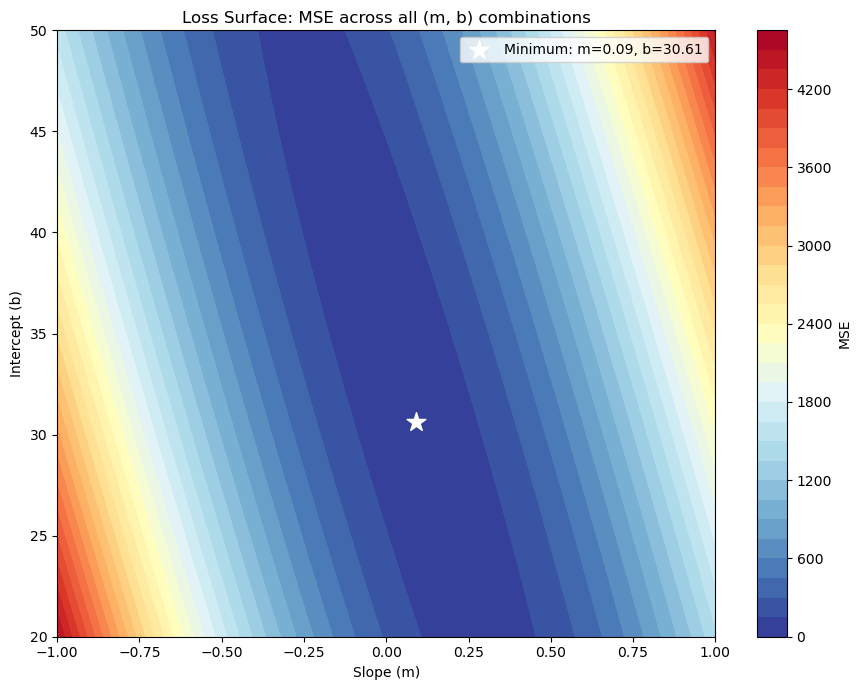

Grid minimum: m=0.09, b=30.61
MSE at minimum: 53.42


In [61]:
m_grid = np.linspace(-1, 1, 100)
b_grid = np.linspace(20, 50, 100)
M, B   = np.meshgrid(m_grid, b_grid)

MSE_surface = np.zeros(M.shape)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        MSE_surface[i, j] = mse(Y, M[i, j] * X + B[i, j])

min_idx   = np.unravel_index(np.argmin(MSE_surface), MSE_surface.shape)
best_m_2d = M[min_idx]
best_b_2d = B[min_idx]

fig, ax = plt.subplots(figsize=(9, 7))
# contour = ax.contourf(M, B, MSE_surface / 1e9, levels=40, cmap='RdYlBu_r')
contour = ax.contourf(M, B, MSE_surface, levels=40, cmap='RdYlBu_r')
cbar    = plt.colorbar(contour, ax=ax)
# cbar.set_label("MSE (billions)")
cbar.set_label("MSE")

ax.scatter(best_m_2d, best_b_2d, color='white', s=200, marker='*',
           zorder=5, label=f'Minimum: m={best_m_2d:.2f}, b={best_b_2d:.2f}')
ax.set_xlabel("Slope (m)")
ax.set_ylabel("Intercept (b)")
ax.set_title("Loss Surface: MSE across all (m, b) combinations")
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}')) # type: ignore
ax.legend()
plt.tight_layout()
plt.savefig("03_loss_surface_2d.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Grid minimum: m={best_m_2d:.2f}, b={best_b_2d:.2f}")
print(f"MSE at minimum: {MSE_surface[min_idx]:,.2f}")

ANSWER HERE

---

## Part 4: Simple Linear Regression


Now you build the actual model. You must do this in two steps: manually first, then with sklearn. The numbers must match.

### 4a: Manual Implementation

Implement the following helper functions exactly as shown in lecture:

    def standard_units(x):
        return (x - np.mean(x)) / np.std(x)

    def correlation(x, y):
        return np.mean(standard_units(x) * standard_units(y))

    def slope(x, y):
        return correlation(x, y) * np.std(y) / np.std(x)

    def intercept(x, y):
        return np.mean(y) - slope(x, y) * np.mean(x)

Compute and print your slope and intercept. Then write out your model equation explicitly:

    predicted [target] = [intercept] + [slope] * [feature]

Interpret both the slope and intercept in plain English using the actual variable names from your dataset. Generic interpretations like "b is the slope" will not receive credit.

In [71]:
def standard_units(X):
    return (X - X.mean()) / X.std()

def correlation(X, Y):
    return np.mean(standard_units(X) * standard_units(Y))

def slope(X, Y):
    return correlation(X, Y) * (Y.std() / X.std())

def intercept(X, Y, m):
    return Y.mean() - m * X.mean()

slope_value = slope(X, Y)
intercept_value = intercept(X, Y, slope_value)
solution = slope_value * X + intercept_value

print(f"Manual intercept:  {intercept_value:.4f}")
print(f"Manual slope:      {slope_value:.4f}")

print(f"Predicted Value {solution[0]} = {intercept_value:.2f} + {slope_value:.4f} * {X[0]}")

Manual intercept:  30.4653
Manual slope:      0.0929
Predicted Value 37.21687131344451 = 30.47 + 0.0929 * 72.69


Interpretation...

### 4b: Sklearn Verification

Fit the same model using sklearn and verify your parameters match:

    from sklearn.linear_model import LinearRegression

    model = LinearRegression()
    model.fit(df[['feature']], df['target'])

    print(model.intercept_)
    print(model.coef_)

You must explicitly confirm that your manual slope and intercept match sklearn's output. If they do not match, you must debug and explain why.

In [68]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X.reshape(-1, 1), Y) # type: ignore

m_sk = sklearn_model.coef_[0]
b_sk = sklearn_model.intercept_

print(f"Sklearn intercept: {b_sk:.4f}")
print(f"Sklearn slope:     {m_sk:.4f}")

# Are these the same as our manual calculations?
print(f"Manual intercept == Sklearn intercept? {'Yes' if np.isclose(intercept_value, b_sk) else 'No'}")
print(f"Manual slope == Sklearn slope? {'Yes' if np.isclose(slope_value, m_sk) else 'No'}")

Sklearn intercept: 30.4653
Sklearn slope:     0.0929
Manual intercept == Sklearn intercept? Yes
Manual slope == Sklearn slope? Yes


### 4c: Visualization

You must produce a scatter plot of your feature versus your target with the regression line overlaid.

**Your plot must include:**
- A meaningful title
- Labeled axes using your actual variable names
- Both the data points and the fitted line clearly visible

Write 3–5 sentences interpreting what the line represents. Does it fit well? Where does it miss? Are there regions where the model is consistently wrong?

---

## Part 5: Model Evaluation


### 5a: Error Comparison

Compute MSE and RMSE for your linear model and compare them directly to your constant model baseline from Part 2.

You must produce a comparison table.

Write 2–3 sentences answering: did your feature provide useful predictive information? How do you know?

In [72]:
y_pred_linear = slope_value * X + intercept_value

linear_mse  = mse(Y, y_pred_linear)
linear_rmse = rmse(Y, y_pred_linear)

print("=== Model Comparison ===")
print(f"{'Model':<20} {'MSE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'Constant baseline':<20} {baseline_mse:>10.2f} {baseline_rmse:>10.2f}")
print(f"{'Linear regression':<20} {linear_mse:>10.2f} {linear_rmse:>10.2f}")
print(f"{'Improvement':<20} {baseline_mse - linear_mse:>10.2f} {baseline_rmse - linear_rmse:>10.2f}")

=== Model Comparison ===
Model                       MSE       RMSE
------------------------------------------
Constant baseline         56.40       7.51
Linear regression         53.42       7.31
Improvement                2.99       0.20


### 5b: R-Squared

Compute R-squared for your linear model:

    r2 = np.var(df['pred_linear']) / np.var(df['target'])

Write 3–5 sentences interpreting your R-squared value. Your interpretation must answer:
- What percentage of variation in your target does your model explain?
- Is that a strong or weak result for your domain?
- What does the remaining unexplained variation tell you about your model?

In [ ]:
r2 = np.var(y_pred_linear) / np.var(Y) # type: ignore
print(f"R-squared: {r2:.4f}")
print(f"R-squared: {r2 * 100:.2f}%")

R-squared: 0.0530
R-squared: 5.30%


### 5c: Actual vs. Predicted Plot

Create a scatter plot of actual values on the x-axis against predicted values on the y-axis. Draw the diagonal reference line where actual equals predicted.

Write 3–5 sentences interpreting this plot. Points on the diagonal represent perfect predictions. What do points above or below the line tell you? Is your model systematically over- or under-predicting in any region?

---

## Part 6: Residual Analysis

Residuals are the errors your model makes. Analyzing them tells you whether your model is capturing the full structure of your data or missing something important.

Compute your residuals and generate a residual plot.

**For your written interpretation, answer all of the following in 4–6 full sentences:**
- What question are you answering with this plot?
- Are the residuals randomly scattered around zero, or do you see a pattern?
- If you see a pattern, what does that tell you about your model?
- Are there any outliers in the residuals? What might explain them?
- Does this plot change your confidence in the model? Why or why not?

> **Important:** A residual plot that shows a clear curve or funnel shape means your linear model is missing structure in the data. That is not failure — that is a finding. Name it and explain it.

---

## Part 7: Multiple Linear Regression (Intro)

Now try adding a second feature to your model. This is an introduction, not a full analysis. The goal is to test whether a second variable provides new information that improves your predictions.

**You must:**
1. Select a second feature from your dataset and justify the choice in 1–2 sentences
2. Fit a multiple linear regression model using sklearn with both features
3. Compute MSE and RMSE for the new model
4. Add the result to your comparison table from Part 5a
5. Interpret whether the second feature helped and why or why not

> **Important:** More features do not automatically mean a better model. They only help if they provide new information. Your job is to test this, not assume it.

Write 3–5 sentences summarizing your findings from this section. Did the second feature improve your model? By how much? Would you keep it in a final model?

---

## Part 8: Reflection

Write two paragraphs.

**Paragraph 1:** Look back at your Phase 2 EDA. What did your visualizations predict about which features would be useful? Was your Phase 2 analysis right? If your model performed differently than you expected, explain why you think that happened.

**Paragraph 2:** Based on your residual plot and your R-squared value, what does your model still get wrong? What would you try next to improve it? What additional data, features, or transformations might help?

> A reflection that says "my model worked well" with no evidence of critical thinking will not receive full credit. The best reflections identify specific weaknesses and propose concrete next steps.

Paragraph 1 Placeholder

Paragraph 2 Placeholder

---

## Grading Criteria


| Part | Description | Points |
|------|-------------|--------|
| Part 1 | Feature and target selection with EDA justification | 10 |
| Part 2 | Constant model baseline with correct MSE/RMSE and interpretation | 10 |
| Part 3 | Loss function implementation and loss surface visualization | 15 |
| Part 4 | Manual SLR implementation, sklearn verification, and visualization | 20 |
| Part 5 | Model evaluation including error comparison, R-squared, and actual vs. predicted plot | 20 |
| Part 6 | Residual analysis with full written interpretation | 15 |
| Part 7 | Multiple linear regression attempt with comparison and interpretation | 5 |
| Part 8 | Reflection | 5 |
| **Total** | | **100** |